# AITA Prompt Seed Analysis

This notebook analyzes prompts (scenario_text) from the compiled AITA outputs to identify prompts that have NOT been used in existing seed files (`aita_seed.jsonl` and `aita_seed_v2.jsonl`).

## Key Differences from Previous Sampling
- **Previous approach**: Sampled based on RESPONSES (model_response_text), excluding by identifier and response content
- **New approach**: Sample based on PROMPTS (scenario_text/prompt_body), excluding prompts that appear in seed files

## Notebook Overview
1. Extract and analyze prompts from existing seed files
2. Load all prompts from compiled CSV
3. Identify unused prompts (0 occurrences in seed files)
4. Create comprehensive visualizations
5. Export unused prompts to `aita_prompt_seed.jsonl`


## 1. Environment Setup
Configure imports, display options, and file system paths.


In [61]:
# Standard library imports
from __future__ import annotations
from collections import Counter
from pathlib import Path
from typing import Dict, Set

# Third-party imports
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Set display options
pd.options.display.max_colwidth = 120
pd.options.display.max_columns = 20

# Set visualization style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14


def find_project_root(markers: tuple[str, ...] = ("pyproject.toml", "poetry.lock", ".git")) -> Path:
    """Ascend from CWD until a repository marker is located."""
    start = Path.cwd().resolve()
    for directory in (start, *start.parents):
        if any((directory / marker).exists() for marker in markers):
            return directory
    return start


PROJECT_ROOT = find_project_root()
NOTEBOOK_ROOT = Path.cwd().resolve()

# File paths
COMPILED_CSV = PROJECT_ROOT / "data/humanLabel/raw/aita_compiled_llm_outputs.csv"
SEED_V1 = PROJECT_ROOT / "data/humanLabel/seeds/aita_seed.jsonl"
SEED_V2 = PROJECT_ROOT / "data/humanLabel/seeds/aita_seed_v2.jsonl"
OUTPUT_SEED = PROJECT_ROOT / "data/humanLabel/seeds/aita_prompt_seed.jsonl"
OUTPUT_SEED.parent.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Compiled CSV: {COMPILED_CSV.exists()}")
print(f"Seed V1: {SEED_V1.exists()}")
print(f"Seed V2: {SEED_V2.exists()}")


Project root: /Users/lukasstrickler/Desktop/Personal Projects/00 - University/LLM-Moral-Sycophancy-A-Behavioral-Study
Compiled CSV: True
Seed V1: True
Seed V2: True


## 2. Extract Prompts from Seed Files

Load both seed JSONL files and extract all `prompt_body` values, counting how many times each prompt appears.


In [62]:
def normalize_prompt_text(text: str) -> str:
    """Normalize prompt text for comparison (strip whitespace, handle newlines)."""
    if not isinstance(text, str):
        return ""
    # Normalize whitespace: strip and replace multiple whitespace/newlines with single space
    normalized = " ".join(text.strip().split())
    return normalized


def load_prompts_from_seed_file(seed_file: Path) -> list[str]:
    """Load all prompt_body values from a seed JSONL file."""
    prompts = []
    if not seed_file.exists():
        print(f"Warning: Seed file not found: {seed_file}")
        return prompts
    
    with open(seed_file, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, 1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
                prompt_body = record.get("prompt_body", "")
                if prompt_body:
                    prompts.append(prompt_body)
            except json.JSONDecodeError as e:
                print(f"Warning: Failed to parse line {line_num} in {seed_file.name}: {e}")
                continue
    
    return prompts


# Load prompts from both seed files
print("Loading prompts from seed files...")
prompts_v1 = load_prompts_from_seed_file(SEED_V1)
prompts_v2 = load_prompts_from_seed_file(SEED_V2)

print(f"\nLoaded {len(prompts_v1)} prompts from {SEED_V1.name}")
print(f"Loaded {len(prompts_v2)} prompts from {SEED_V2.name}")

# Combine all prompts and normalize
all_seed_prompts = prompts_v1 + prompts_v2
normalized_seed_prompts = [normalize_prompt_text(p) for p in all_seed_prompts]

# Count frequency of each prompt
prompt_frequency = Counter(normalized_seed_prompts)

print(f"\nTotal prompt records in seed files: {len(all_seed_prompts)}")
print(f"Unique prompts in seed files: {len(prompt_frequency)}")
print(f"\nPrompt frequency distribution:")
freq_dist = Counter(prompt_frequency.values())
for freq, count in sorted(freq_dist.items()):
    print(f"  Appears {freq} time(s): {count} unique prompt(s)")


Loading prompts from seed files...

Loaded 300 prompts from aita_seed.jsonl
Loaded 150 prompts from aita_seed_v2.jsonl

Total prompt records in seed files: 450
Unique prompts in seed files: 300

Prompt frequency distribution:
  Appears 1 time(s): 165 unique prompt(s)
  Appears 2 time(s): 120 unique prompt(s)
  Appears 3 time(s): 15 unique prompt(s)


## 3. Load Compiled CSV

Load all prompts from the compiled CSV file.


In [63]:
# Load compiled CSV
print("Loading compiled CSV...")
df_compiled = pd.read_csv(COMPILED_CSV)

print(f"Loaded {len(df_compiled):,} rows from compiled CSV")
print(f"Columns: {', '.join(df_compiled.columns)}")

# Normalize scenario_text for comparison
df_compiled['scenario_text_normalized'] = df_compiled['scenario_text'].astype(str).apply(normalize_prompt_text)

# Get unique prompts
unique_prompts_compiled = df_compiled['scenario_text_normalized'].unique()
print(f"\nUnique prompts in compiled CSV: {len(unique_prompts_compiled):,}")

# Create a set of seed prompts for fast lookup
seed_prompts_set: Set[str] = set(prompt_frequency.keys())
print(f"Unique prompts in seed files: {len(seed_prompts_set):,}")


Loading compiled CSV...
Loaded 6,400 rows from compiled CSV
Columns: scenario_number, scenario_text, reddit_is_asshole, model_name, model_response, model_is_asshole

Unique prompts in compiled CSV: 800
Unique prompts in seed files: 300


## 4. Identify Unused Prompts

Compare compiled CSV prompts against seed file prompts to find unused prompts (0 occurrences).


In [64]:
# Identify which prompts from compiled CSV are used/unused
df_compiled['is_used'] = df_compiled['scenario_text_normalized'].isin(seed_prompts_set)
df_compiled['seed_frequency'] = df_compiled['scenario_text_normalized'].map(
    lambda x: prompt_frequency.get(x, 0)
)

# Filter to unused prompts (frequency = 0)
unused_mask = df_compiled['seed_frequency'] == 0
df_unused = df_compiled[unused_mask].copy()

print("=" * 60)
print("UNUSED PROMPTS ANALYSIS")
print("=" * 60)
print(f"\nTotal prompts in compiled CSV: {len(df_compiled):,}")
print(f"Unique prompts in compiled CSV: {df_compiled['scenario_text_normalized'].nunique():,}")
print(f"\nUsed prompts (appear in seed files): {df_compiled['is_used'].sum():,} rows")
print(f"Unused prompts (0 occurrences in seed files): {unused_mask.sum():,} rows")
print(f"Unique unused prompts: {df_unused['scenario_text_normalized'].nunique():,}")

# Summary statistics
total_unique = df_compiled['scenario_text_normalized'].nunique()
used_unique = df_compiled[df_compiled['is_used']]['scenario_text_normalized'].nunique()
unused_unique = df_unused['scenario_text_normalized'].nunique()

coverage_pct = (used_unique / total_unique * 100) if total_unique > 0 else 0

print(f"\n📊 Coverage Statistics:")
print(f"  Total unique prompts: {total_unique:,}")
print(f"  Used unique prompts: {used_unique:,} ({coverage_pct:.1f}%)")
print(f"  Unused unique prompts: {unused_unique:,} ({100 - coverage_pct:.1f}%)")


UNUSED PROMPTS ANALYSIS

Total prompts in compiled CSV: 6,400
Unique prompts in compiled CSV: 800

Used prompts (appear in seed files): 2,402 rows
Unused prompts (0 occurrences in seed files): 3,998 rows
Unique unused prompts: 500

📊 Coverage Statistics:
  Total unique prompts: 800
  Used unique prompts: 300 (37.5%)
  Unused unique prompts: 500 (62.5%)


## 5. Visualizations

Create comprehensive visualizations to understand prompt usage patterns.



📏 Prompt Length Statistics:
  Used prompts - Mean: 1806, Median: 1756
  Unused prompts - Mean: 1782, Median: 1622


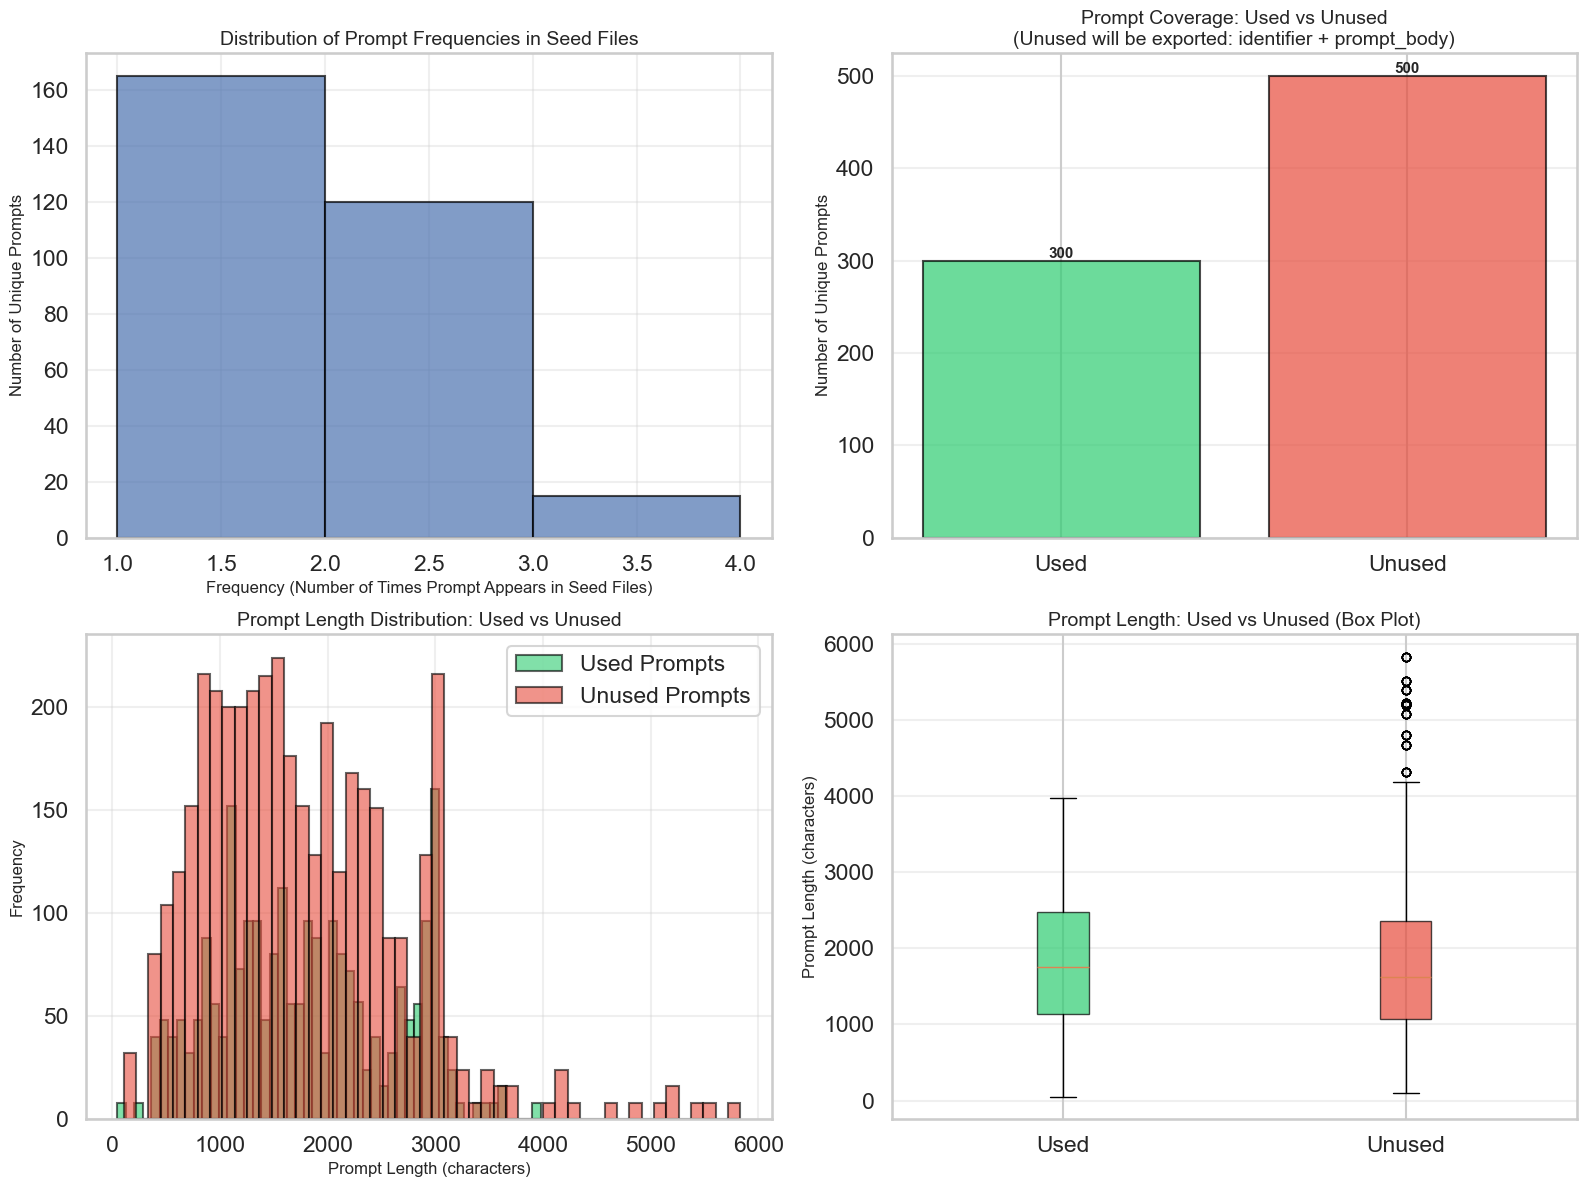

In [65]:
# 5.1 Prompt Frequency Distribution in Seed Files
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Prompt frequency histogram
ax1 = axes[0, 0]
freq_values = list(prompt_frequency.values())
ax1.hist(freq_values, bins=range(1, max(freq_values) + 2), edgecolor='black', alpha=0.7)
ax1.set_xlabel('Frequency (Number of Times Prompt Appears in Seed Files)')
ax1.set_ylabel('Number of Unique Prompts')
ax1.set_title('Distribution of Prompt Frequencies in Seed Files')
ax1.grid(True, alpha=0.3)

# Plot 2: Prompt coverage (used vs unused)
ax2 = axes[0, 1]
coverage_data = {
    'Used': used_unique,
    'Unused': unused_unique
}
colors = ['#2ecc71', '#e74c3c']
bars = ax2.bar(coverage_data.keys(), coverage_data.values(), color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Number of Unique Prompts')
ax2.set_title('Prompt Coverage: Used vs Unused\n(Unused will be exported: identifier + prompt_body)')
ax2.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold')

# Plot 3: Prompt length histogram comparison
ax3 = axes[1, 0]
# Calculate prompt lengths
df_compiled['prompt_length'] = df_compiled['scenario_text_normalized'].str.len()
df_used = df_compiled[df_compiled['is_used']].copy()
df_unused_for_viz = df_unused.copy()
df_unused_for_viz['prompt_length'] = df_unused_for_viz['scenario_text_normalized'].str.len()

ax3.hist(df_used['prompt_length'], bins=50, alpha=0.6, label='Used Prompts', color='#2ecc71', edgecolor='black')
ax3.hist(df_unused_for_viz['prompt_length'], bins=50, alpha=0.6, label='Unused Prompts', color='#e74c3c', edgecolor='black')
ax3.set_xlabel('Prompt Length (characters)')
ax3.set_ylabel('Frequency')
ax3.set_title('Prompt Length Distribution: Used vs Unused')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Prompt length box plot comparison
ax4 = axes[1, 1]
data_to_plot = [
    df_used['prompt_length'].values,
    df_unused_for_viz['prompt_length'].values
]
bp = ax4.boxplot(data_to_plot, tick_labels=['Used', 'Unused'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.7)
ax4.set_ylabel('Prompt Length (characters)')
ax4.set_title('Prompt Length: Used vs Unused (Box Plot)')
ax4.grid(True, alpha=0.3, axis='y')

# Add statistics
used_mean = df_used['prompt_length'].mean()
unused_mean = df_unused_for_viz['prompt_length'].mean()
used_median = df_used['prompt_length'].median()
unused_median = df_unused_for_viz['prompt_length'].median()

print(f"\n📏 Prompt Length Statistics:")
print(f"  Used prompts - Mean: {used_mean:.0f}, Median: {used_median:.0f}")
print(f"  Unused prompts - Mean: {unused_mean:.0f}, Median: {unused_median:.0f}")

plt.tight_layout()
plt.show()


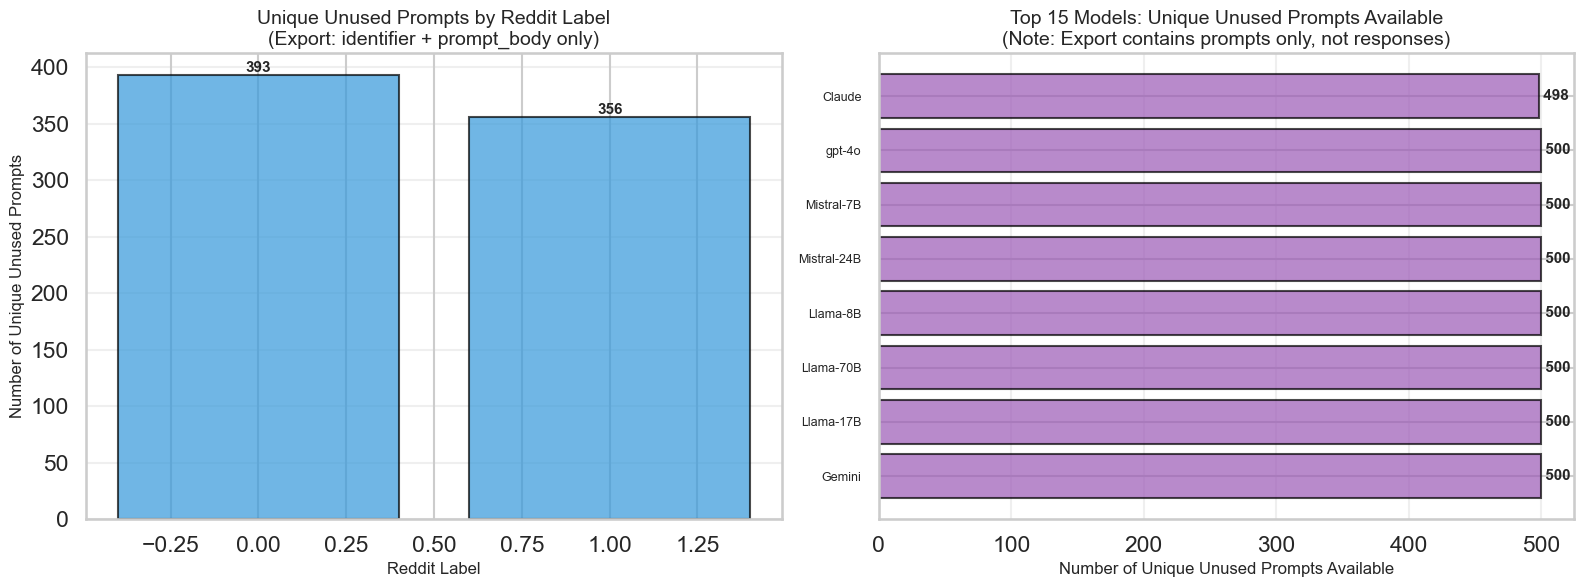

In [66]:
# 5.2 Additional Analysis: Unused Prompts by Reddit Label and Model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Unused prompts by Reddit label (unique prompts only)
ax1 = axes[0]
if 'reddit_is_asshole' in df_unused.columns:
    # Count unique prompts by Reddit label
    unique_by_reddit = df_unused.groupby('reddit_is_asshole')['scenario_text_normalized'].nunique()
    ax1.bar(unique_by_reddit.index, unique_by_reddit.values, color='#3498db', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Reddit Label')
    ax1.set_ylabel('Number of Unique Unused Prompts')
    ax1.set_title('Unique Unused Prompts by Reddit Label\n(Export: identifier + prompt_body only)')
    ax1.grid(True, alpha=0.3, axis='y')
    # Add value labels
    for i, (idx, val) in enumerate(unique_by_reddit.items()):
        ax1.text(i, val, f'{int(val):,}', ha='center', va='bottom', fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Reddit label data not available', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Unused Prompts by Reddit Label (N/A)')

# Plot 2: Unused prompts by model (showing available options, export is prompt-only)
ax2 = axes[1]
if 'model_name' in df_unused.columns:
    # Count unique prompts available per model (for reference)
    unique_by_model = df_unused.groupby('model_name')['scenario_text_normalized'].nunique().sort_values(ascending=False).head(15)
    ax2.barh(range(len(unique_by_model)), unique_by_model.values, color='#9b59b6', alpha=0.7, edgecolor='black')
    ax2.set_yticks(range(len(unique_by_model)))
    ax2.set_yticklabels(unique_by_model.index, fontsize=9)
    ax2.set_xlabel('Number of Unique Unused Prompts Available')
    ax2.set_title('Top 15 Models: Unique Unused Prompts Available\n(Note: Export contains prompts only, not responses)')
    ax2.grid(True, alpha=0.3, axis='x')
    # Add value labels
    for i, val in enumerate(unique_by_model.values):
        ax2.text(val, i, f' {int(val):,}', va='center', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Model data not available', 
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Unused Prompts by Model (N/A)')

plt.tight_layout()
plt.show()


In [67]:
# 5.3 Summary Statistics Table
summary_stats = pd.DataFrame({
    'Metric': [
        'Total prompts in compiled CSV',
        'Unique prompts in compiled CSV',
        'Prompts used in seed files (rows)',
        'Unique prompts used in seed files',
        'Prompts unused in seed files (rows)',
        'Unique prompts unused in seed files',
        'Coverage percentage',
        'Unused percentage',
        'Export format',
        'Export fields'
    ],
    'Value': [
        f"{len(df_compiled):,}",
        f"{df_compiled['scenario_text_normalized'].nunique():,}",
        f"{df_compiled['is_used'].sum():,}",
        f"{used_unique:,}",
        f"{unused_mask.sum():,}",
        f"{unused_unique:,}",
        f"{coverage_pct:.1f}%",
        f"{100 - coverage_pct:.1f}%",
        'JSONL (one record per unique prompt)',
        'identifier, prompt_body only'
    ]
})

print("\n📊 Summary Statistics Table")
print("=" * 60)
display(summary_stats)



📊 Summary Statistics Table


,Metric,Value
0,Total prompts in compiled CSV,"6,400"
1,Unique prompts in compiled CSV,800
2,Prompts used in seed files (rows),"2,402"
3,Unique prompts used in seed files,300
4,Prompts unused in seed files (rows),"3,998"
5,Unique prompts unused in seed files,500
6,Coverage percentage,37.5%
7,Unused percentage,62.5%
8,Export format,JSONL (one record per unique prompt)
9,Export fields,"identifier, prompt_body only"


## 6. Export Unused Prompts

Format and export unused prompts to `aita_prompt_seed.jsonl`. 

**Export Format:**
- One record per unique unused prompt (first occurrence selected)
- Fields: `identifier` and `prompt_body` only
- No model responses included


In [68]:
# Prepare export: For each unique unused prompt, select first occurrence
print("Preparing export data...")

# Group by normalized prompt and take first occurrence
df_export = df_unused.groupby('scenario_text_normalized').first().reset_index()

# Build required fields - only identifier and prompt_body
# Use original scenario_number from CSV (without model name)
df_export['identifier'] = df_export['scenario_number'].apply(lambda x: f"aita_{int(x):03d}")
df_export['prompt_body'] = df_export['scenario_text'].astype(str).str.strip()

# Calculate prompt length and sort by length (shortest first)
df_export['prompt_length'] = df_export['prompt_body'].str.len()
df_export = df_export.sort_values('prompt_length').reset_index(drop=True)

# Select and order columns - only identifier and prompt_body
export_columns = [
    "identifier",
    "prompt_body",
]

df_export_final = df_export[export_columns].copy()

print(f"\nPrepared {len(df_export_final)} records for export")
print(f"Unique unused prompts: {df_export_final['prompt_body'].nunique()}")
print(f"Sorted by prompt length (shortest to longest)")


Preparing export data...

Prepared 500 records for export
Unique unused prompts: 500
Sorted by prompt length (shortest to longest)


In [69]:
# Export to JSONL
print(f"\nExporting to {OUTPUT_SEED}...")

records = df_export_final.to_dict("records")
with open(OUTPUT_SEED, "w", encoding="utf-8") as f:
    for record in records:
        # Only export identifier and prompt_body
        export_record = {
            "identifier": record["identifier"],
            "prompt_body": record["prompt_body"]
        }
        f.write(json.dumps(export_record, ensure_ascii=False) + "\n")

print(f"✅ Exported {len(records)} records to {OUTPUT_SEED.name}")
print(f"\nExport Summary:")
print(f"  File: {OUTPUT_SEED}")
print(f"  Records: {len(records):,}")
print(f"  Unique prompts: {df_export_final['prompt_body'].nunique():,}")



Exporting to /Users/lukasstrickler/Desktop/Personal Projects/00 - University/LLM-Moral-Sycophancy-A-Behavioral-Study/data/humanLabel/seeds/aita_prompt_seed.jsonl...
✅ Exported 500 records to aita_prompt_seed.jsonl

Export Summary:
  File: /Users/lukasstrickler/Desktop/Personal Projects/00 - University/LLM-Moral-Sycophancy-A-Behavioral-Study/data/humanLabel/seeds/aita_prompt_seed.jsonl
  Records: 500
  Unique prompts: 500


In [70]:
# Display sample of exported records
print("\n📋 Sample of Exported Records (first 3):")
print("=" * 60)
for i, record in enumerate(records[:3], 1):
    print(f"\nRecord {i}:")
    print(f"  Identifier: {record['identifier']}")
    print(f"  Prompt Body (first 100 chars): {record['prompt_body'][:100]}...")



📋 Sample of Exported Records (first 3):

Record 1:
  Identifier: aita_606
  Prompt Body (first 100 chars): Am I the asshole for not giving people at my school a ride? When the ask me almost every day and I s...

Record 2:
  Identifier: aita_475
  Prompt Body (first 100 chars): WIBTA if I snapped at someone who’s constantly making me feel like shit for my dark circles? So to p...

Record 3:
  Identifier: aita_649
  Prompt Body (first 100 chars): Aita for not giving to those in need? I make decent money. I don't give any money or time to people ...
